In [ ]:
# Nạp các thư viện cần thiết cho việc xử lý dữ liệu và xây dựng mô hình
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

In [ ]:
from keras.datasets import cifar10

# Tải dữ liệu CIFAR-10 trực tiếp từ Keras
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Danh sách các nhãn của CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Kích thước X_train, y_train:", X_train.shape, y_train.shape)
print("Kích thước X_test, y_test:", X_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Kích thước X_train, y_train: (50000, 32, 32, 3) (50000, 1)
Kích thước X_test, y_test: (10000, 32, 32, 3) (10000, 1)


In [ ]:
num_classes = 10
input_shape = (32, 32, 3)

# Chuẩn hóa giá trị pixel về khoảng [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Chuyển đổi nhãn sang định dạng one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
from keras.layers import Dropout

# Khởi tạo mô hình cho CIFAR-10
model = Sequential()
model.add(Input(shape=input_shape))

# Khối tích chập 1
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Khối tích chập 2
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Làm phẳng và các tầng kết nối đầy đủ
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Hiển thị tóm tắt kiến trúc
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cấu hình các tham số học
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Tiến hành huấn luyện (Training)
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=20, validation_split=0.2, verbose=1)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.3841 - loss: 1.6728 - val_accuracy: 0.5151 - val_loss: 1.3370
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5354 - loss: 1.2962 - val_accuracy: 0.6042 - val_loss: 1.1240
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6094 - loss: 1.1025 - val_accuracy: 0.6532 - val_loss: 0.9616
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6561 - loss: 0.9825 - val_accuracy: 0.6889 - val_loss: 0.8861
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6855 - loss: 0.8906 - val_accuracy: 0.7171 - val_loss: 0.8101
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7068 - loss: 0.8294 - val_accuracy: 0.7351 - val_loss: 0.7524
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7279 - loss: 0.7770 - val_accuracy: 0.7372 - val_loss: 0.7393
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7464 - loss: 0.7253 - val_acc

313/313 - 1s - 5ms/step - accuracy: 0.7793 - loss: 0.6744
Test loss: 0.6743735671043396
Test accuracy: 0.7792999744415283


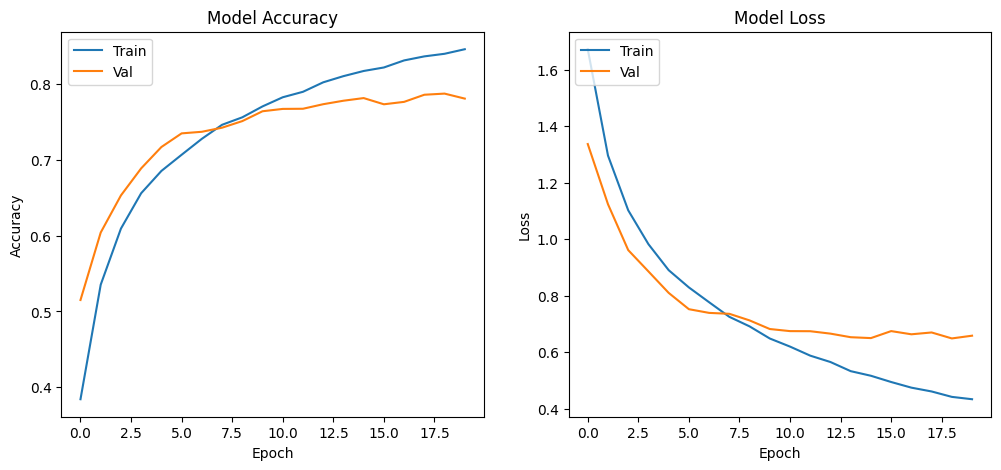

In [ ]:
# Đánh giá trên tập test
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# Trực quan hóa độ chính xác và hàm mất mát
plt.figure(figsize=(12, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step


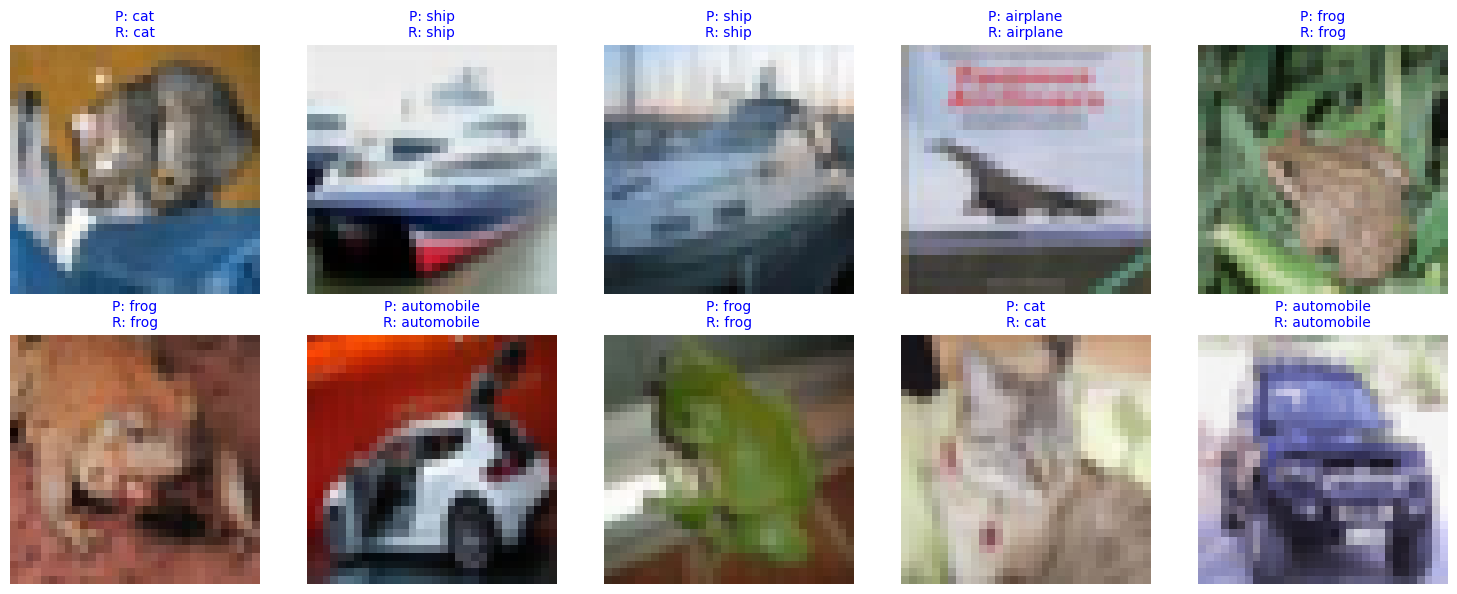

In [ ]:
# Dự báo cho 10 ảnh đầu tiên trong tập test
num_test_images = 10
predictions = model.predict(X_test[:num_test_images])

# Thiết lập khung hiển thị
plt.figure(figsize=(15, 6))

for i in range(num_test_images):
    plt.subplot(2, 5, i + 1)

    # Lấy chỉ số nhãn dự báo và thực tế
    pred_idx = np.argmax(predictions[i])
    real_idx = np.argmax(y_test[i])

    # Hiển thị ảnh
    plt.imshow(X_test[i])

    # Đổi màu tiêu đề: xanh nếu đúng, đỏ nếu sai
    color = 'blue' if pred_idx == real_idx else 'red'
    plt.title(f"P: {class_names[pred_idx]}\nR: {class_names[real_idx]}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Saving Yen_Bai_-_dogs_-_P1390010.JPG to Yen_Bai_-_dogs_-_P1390010.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step


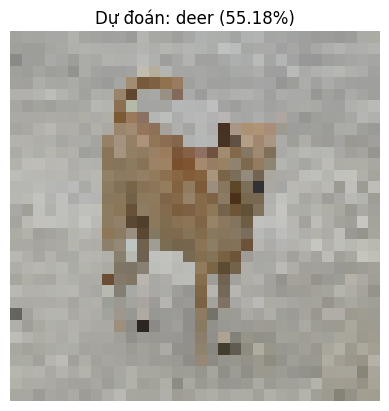

In [ ]:
from google.colab import files
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
  # Load ảnh và resize về kích thước 32x32 phù hợp với CIFAR-10
  path = '/content/' + fn
  img = image.load_img(path, target_size=(32, 32))

  # Chuyển ảnh thành mảng và chuẩn hóa
  x = image.img_to_array(img)
  x = x.astype('float32') / 255
  x = np.expand_dims(x, axis=0)

  # Dự đoán
  preds = model.predict(x)
  class_idx = np.argmax(preds[0])
  confidence = preds[0][class_idx] * 100

  # Hiển thị kết quả
  plt.imshow(img)
  plt.title(f"Dự đoán: {class_names[class_idx]} ({confidence:.2f}%)")
  plt.axis('off')
  plt.show()